In [1]:
# --- Colab setup ---

import os
import sys

# Clone the repo
!git clone https://github.com/AhmedAbdelaal2001/drifting-playground.git

# Move into repo directory
%cd drifting-playground

# Install dependencies
!pip install -r requirements.txt

# Make sure Python can import your modules
sys.path.append(os.getcwd())

print("Setup complete.")

Cloning into 'drifting-playground'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 51 (delta 17), reused 41 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 317.37 KiB | 8.58 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/drifting-playground
Setup complete.


# Toy Drifting Model on 2D datasets (moons / spirals / gaussian mixture)

This notebook implements the core of **Generative Modeling via Drifting** on simple 2D datasets:

- Generator `fθ: z -> x`
- Drifting field `V(x, y_pos, y_neg, T)` (Alg. 2)
- Training step using a stop-gradient drifted target (Alg. 1)

All non-core code (datasets, plotting, config IO) lives in `drifting_helpers/`.

In [2]:
from __future__ import annotations

from pathlib import Path
import math
import os

import torch
import torch.nn as nn
import torch.nn.functional as F

from drifting_helpers.io import load_config
from drifting_helpers.utils import set_global_seed, get_device
from drifting_helpers.data import make_real_sampler
from drifting_helpers.plotting import plot_dataset_preview, plot_training_state, save_fig

# --- config ---
CFG_PATH = "configs/toy_drifting.yaml"   # <-- change this to try other configs
cfg = load_config(CFG_PATH)

# --- output directory ---
run_dir = Path(cfg["logging"]["run_dir"])
run_dir.mkdir(parents=True, exist_ok=True)

# --- device / seed ---
device = get_device(cfg["system"])
set_global_seed(cfg["system"]["seed"])

print("Config:", CFG_PATH)
print("Run dir:", run_dir.resolve())
print("Device:", device)

Config: configs/toy_drifting.yaml
Run dir: /content/drifting-playground/runs/gaussians_seed0
Device: cuda


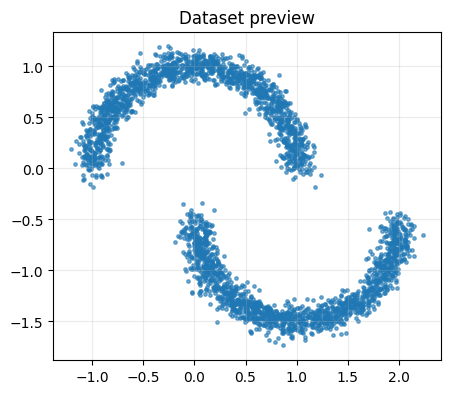

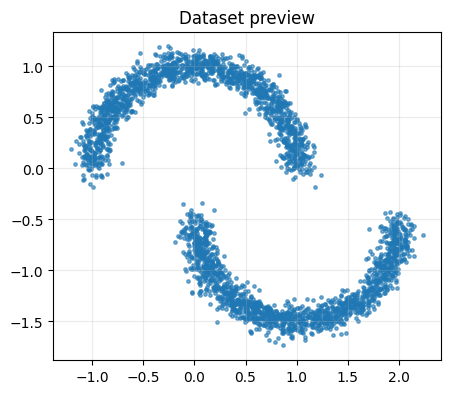

In [3]:
# Real sampler (external)
sample_real = make_real_sampler(cfg, device=device)

# Preview plot (external)
fig = plot_dataset_preview(sample_real, n=cfg["logging"]["n_preview"])
save_fig(fig, run_dir / "dataset_preview.png")
fig

In [4]:
@torch.no_grad()
def compute_V(
    x: torch.Tensor,
    y_pos: torch.Tensor,
    y_neg: torch.Tensor,
    *,
    T: float,
    ignore_self_in_y_neg: bool,
    eps: float = 1e-12,
) -> torch.Tensor:
    """
    Compute drifting field V(x) as described in Algorithm 2 of
    'Generative Modeling via Drifting'.

    Args:
        x:      [N, D] generated samples.
        y_pos:  [N_pos, D] positive samples drawn from pdata.
        y_neg:  [N_neg, D] negative samples drawn from q (often y_neg == x).
        T:      temperature (> 0). Lower => sharper kernel.
        ignore_self_in_y_neg: if True and y_neg corresponds to x, mask diagonal.
        eps:    numerical stability.

    Returns:
        V: [N, D] drift vectors for each x_i.
    """
    if x.ndim != 2 or y_pos.ndim != 2 or y_neg.ndim != 2:
        raise ValueError("x, y_pos, y_neg must be rank-2 tensors [N, D].")
    if x.shape[1] != y_pos.shape[1] or x.shape[1] != y_neg.shape[1]:
        raise ValueError("Feature dimension mismatch across x/y_pos/y_neg.")
    if T <= 0:
        raise ValueError("T must be > 0.")

    N = x.shape[0]
    N_pos = y_pos.shape[0]
    N_neg = y_neg.shape[0]

    # Pairwise L2 distances
    dist_pos = torch.cdist(x, y_pos)  # [N, N_pos]
    dist_neg = torch.cdist(x, y_neg)  # [N, N_neg]

    # Optional: ignore self-matches when y_neg comes from x
    if ignore_self_in_y_neg and N_neg == N:
        dist_neg = dist_neg + torch.eye(N, device=x.device, dtype=x.dtype) * 1e6

    # logits = -||x-y|| / T
    logit_pos = -dist_pos / T
    logit_neg = -dist_neg / T
    logit = torch.cat([logit_pos, logit_neg], dim=1)  # [N, N_pos+N_neg]

    # "double normalization" (row/col softmax) + geometric mean
    A_row = torch.softmax(logit, dim=-1)
    A_col = torch.softmax(logit, dim=-2)
    A = torch.sqrt(torch.clamp(A_row * A_col, min=eps))

    # split back
    A_pos = A[:, :N_pos]         # [N, N_pos]
    A_neg = A[:, N_pos:]         # [N, N_neg]

    # weights (Alg. 2)
    W_pos = A_pos * A_neg.sum(dim=1, keepdim=True)
    W_neg = A_neg * A_pos.sum(dim=1, keepdim=True)

    drift_pos = W_pos @ y_pos    # [N, D]
    drift_neg = W_neg @ y_neg    # [N, D]
    return drift_pos - drift_neg

In [5]:
class ToyGenerator(nn.Module):
    """
    Simple MLP generator: z ~ N(0, I) -> x in R^D (here D=2).
    """
    def __init__(self, *, z_dim: int, hidden_dim: int, n_layers: int, out_dim: int):
        super().__init__()
        self.z_dim = int(z_dim)

        layers: list[nn.Module] = []
        d = self.z_dim
        for _ in range(int(n_layers)):
            layers.append(nn.Linear(d, int(hidden_dim)))
            layers.append(nn.SiLU())
            d = int(hidden_dim)
        layers.append(nn.Linear(d, int(out_dim)))
        self.net = nn.Sequential(*layers)

        # sensible init for MLP
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def sample_z(self, n: int, *, device: torch.device) -> torch.Tensor:
        return torch.randn(n, self.z_dim, device=device)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)

In [6]:
gen_cfg = cfg["generator"]
train_cfg = cfg["training"]
drift_cfg = cfg["drift"]

gen = ToyGenerator(
    z_dim=gen_cfg["z_dim"],
    hidden_dim=gen_cfg["hidden_dim"],
    n_layers=gen_cfg["n_layers"],
    out_dim=gen_cfg["out_dim"],
).to(device)

opt = torch.optim.AdamW(
    gen.parameters(),
    lr=train_cfg["lr"],
    weight_decay=train_cfg["weight_decay"],
)

print(gen)

ToyGenerator(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SiLU()
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)


step    200/4000 | loss=0.000034 | mean||V||=0.035175
step    400/4000 | loss=0.000010 | mean||V||=0.018787
step    600/4000 | loss=0.000011 | mean||V||=0.020100
step    800/4000 | loss=0.000012 | mean||V||=0.021237
step   1000/4000 | loss=0.000006 | mean||V||=0.015046
step   1200/4000 | loss=0.000008 | mean||V||=0.016315
step   1400/4000 | loss=0.000007 | mean||V||=0.016969
step   1600/4000 | loss=0.000007 | mean||V||=0.015357
step   1800/4000 | loss=0.000005 | mean||V||=0.014593
step   2000/4000 | loss=0.000006 | mean||V||=0.015147
step   2200/4000 | loss=0.000006 | mean||V||=0.015691
step   2400/4000 | loss=0.000004 | mean||V||=0.012904
step   2600/4000 | loss=0.000005 | mean||V||=0.013293
step   2800/4000 | loss=0.000004 | mean||V||=0.013404
step   3000/4000 | loss=0.000007 | mean||V||=0.017040
step   3200/4000 | loss=0.000004 | mean||V||=0.012135
step   3400/4000 | loss=0.000007 | mean||V||=0.016759
step   3600/4000 | loss=0.000006 | mean||V||=0.015366
step   3800/4000 | loss=0.00

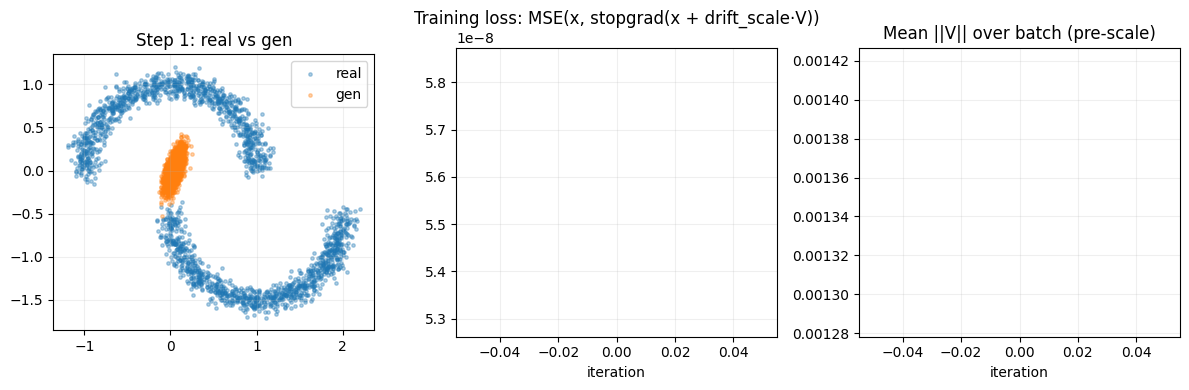

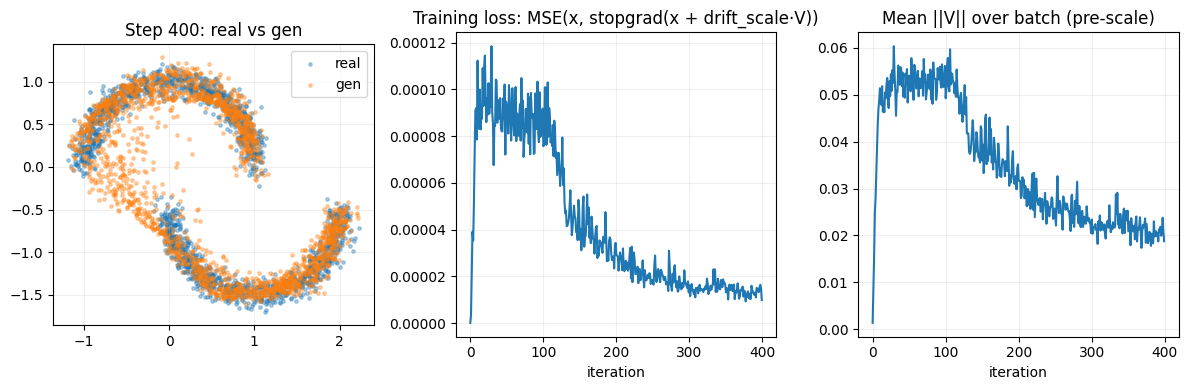

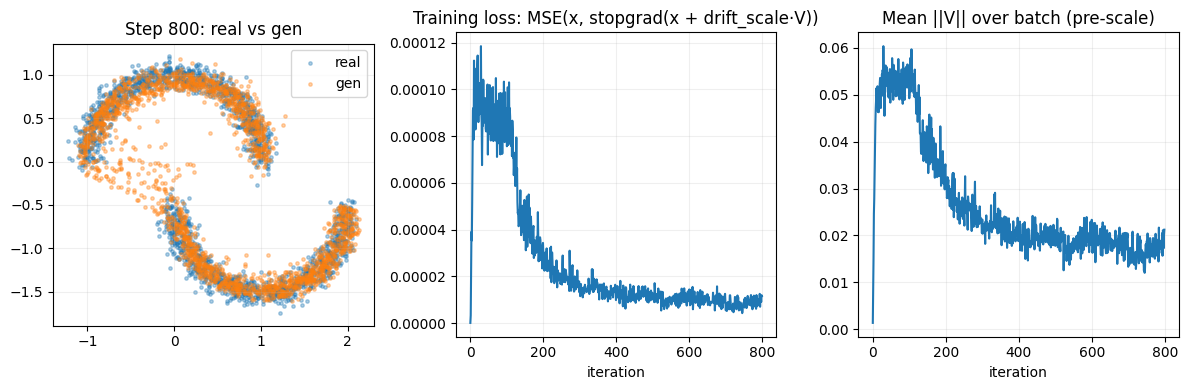

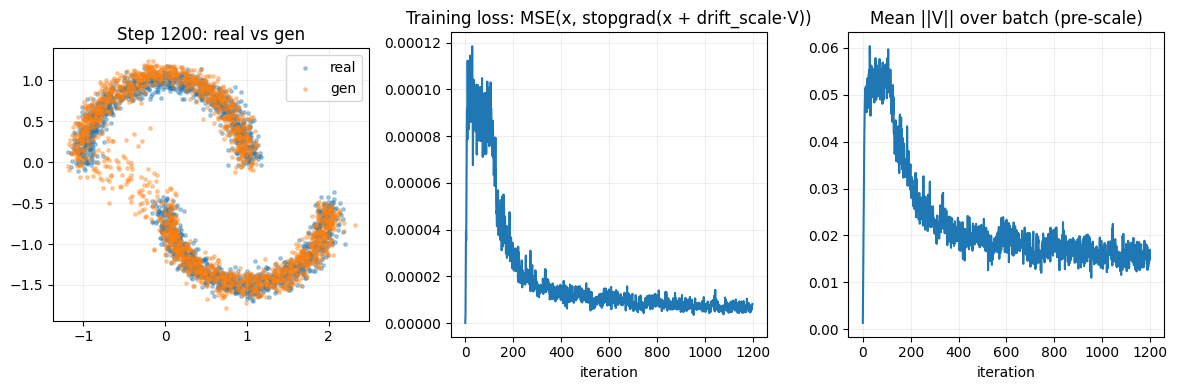

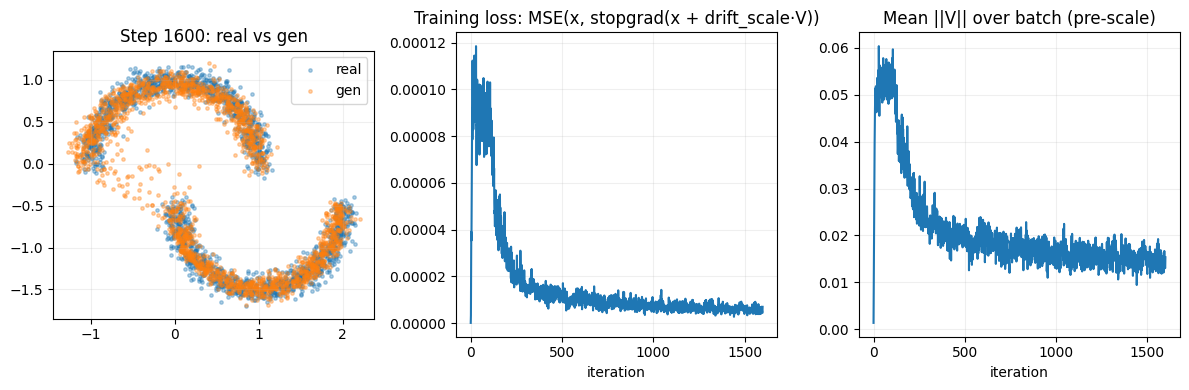

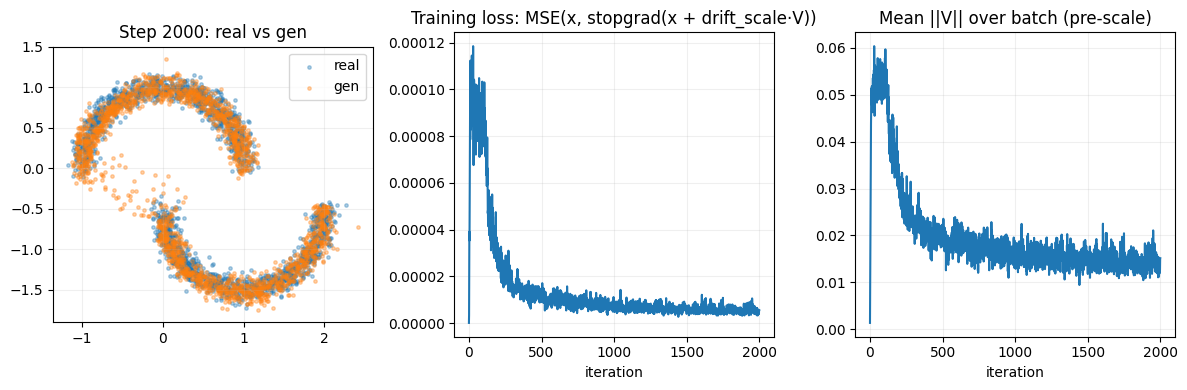

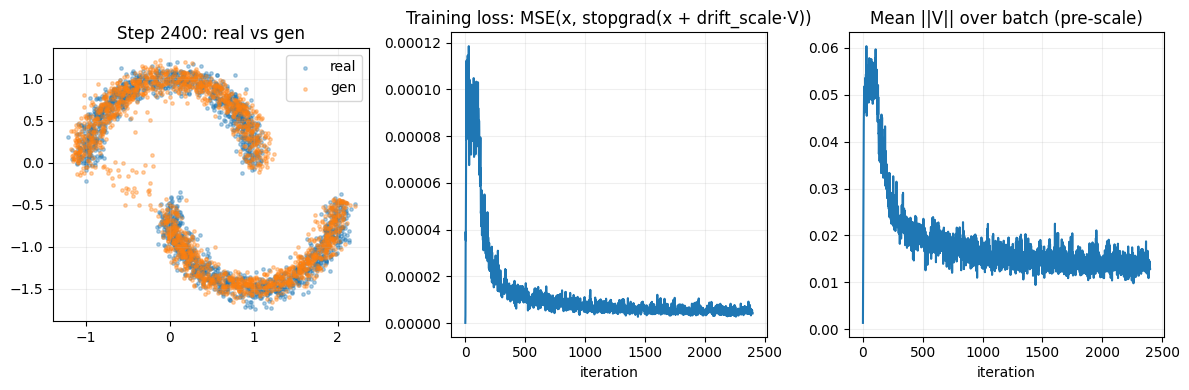

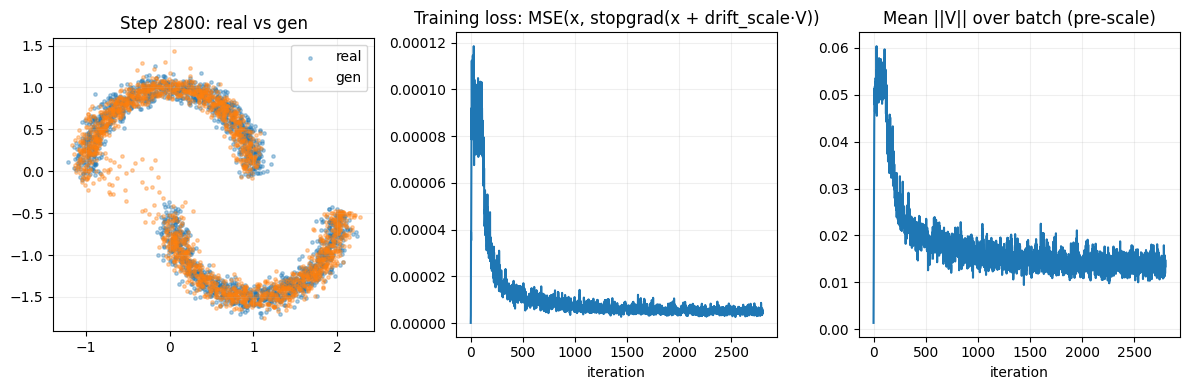

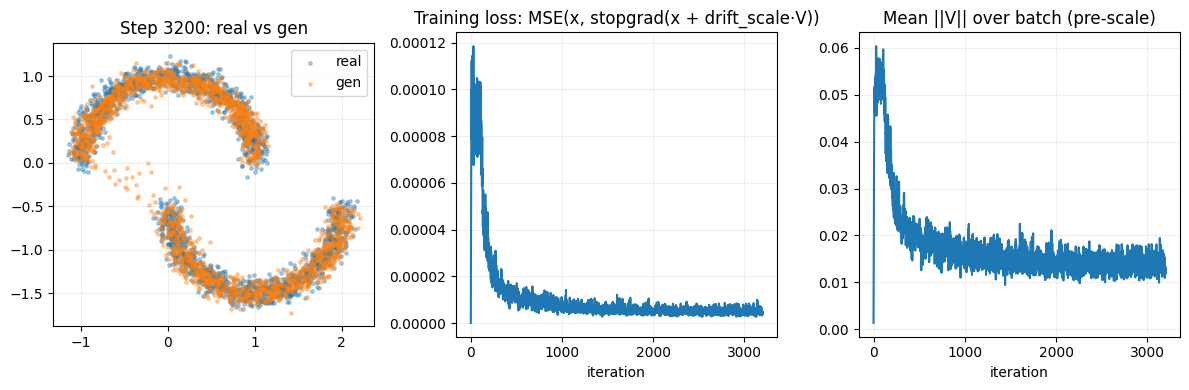

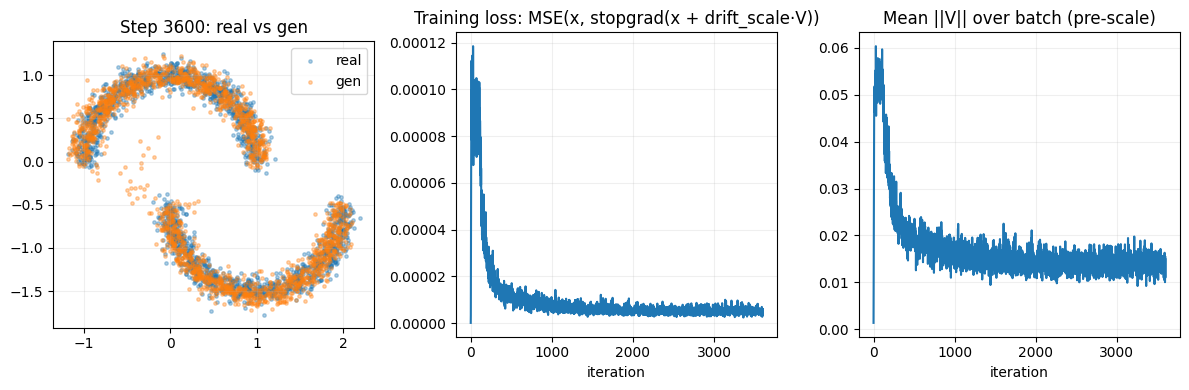

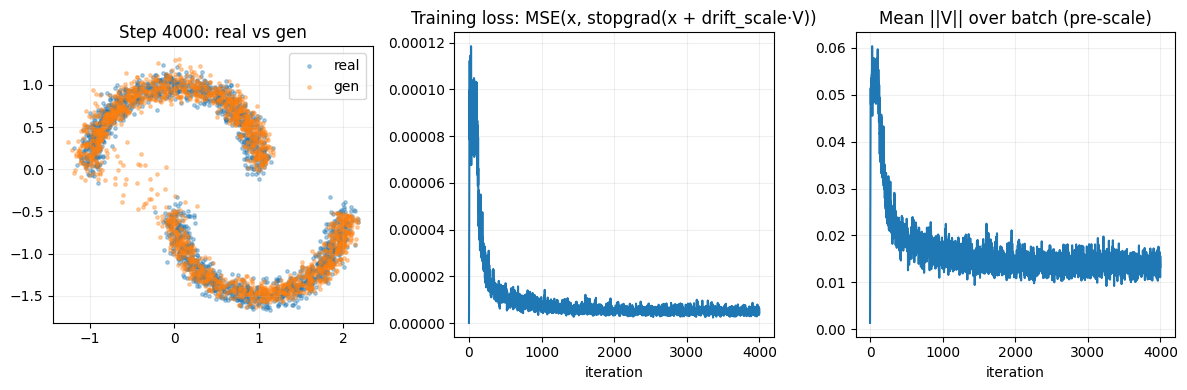

In [7]:
steps = int(train_cfg["steps"])
batch_size = int(train_cfg["batch_size"])
n_pos = int(train_cfg["n_pos"])

T = float(drift_cfg["T"])
drift_scale = float(drift_cfg["drift_scale"])

print_every = int(cfg["logging"]["print_every"])
plot_every = int(cfg["logging"]["plot_every"])
n_vis = int(cfg["logging"]["n_vis"])

# logs
losses: list[float] = []
mean_v_norms: list[float] = []

gen.train()
for step in range(1, steps + 1):
    # sample generator outputs
    z = gen.sample_z(batch_size, device=device)
    x = gen(z)                         # [N, 2]

    # positives: pdata
    y_pos = sample_real(n_pos)         # [N_pos, 2]

    # negatives: reuse generated batch
    y_neg = x                          # [N, 2]

    with torch.no_grad():
        V = compute_V(
            x=x,
            y_pos=y_pos,
            y_neg=y_neg,
            T=T,
            ignore_self_in_y_neg=True,
        )                               # [N, 2]

        x_target = (x + drift_scale * V)  # drifted target
        x_target = x_target.detach()      # stopgrad (Alg. 1 / Eq. 6)

    # regression towards frozen target
    loss = F.mse_loss(x, x_target)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    # logging
    with torch.no_grad():
        losses.append(float(loss.item()))
        mean_v_norms.append(float(V.norm(dim=1).mean().item()))

    if step % print_every == 0:
        print(
            f"step {step:6d}/{steps} | "
            f"loss={losses[-1]:.6f} | mean||V||={mean_v_norms[-1]:.6f}"
        )

    if step == 1 or step % plot_every == 0:
        # plot state externally
        gen.eval()
        fig = plot_training_state(
            sample_real=sample_real,
            sample_fake=lambda n: gen(gen.sample_z(n, device=device)).detach(),
            losses=losses,
            mean_v_norms=mean_v_norms,
            step=step,
            n_vis=n_vis,
        )
        save_fig(fig, run_dir / f"state_step_{step:06d}.png")
        fig
        gen.train()

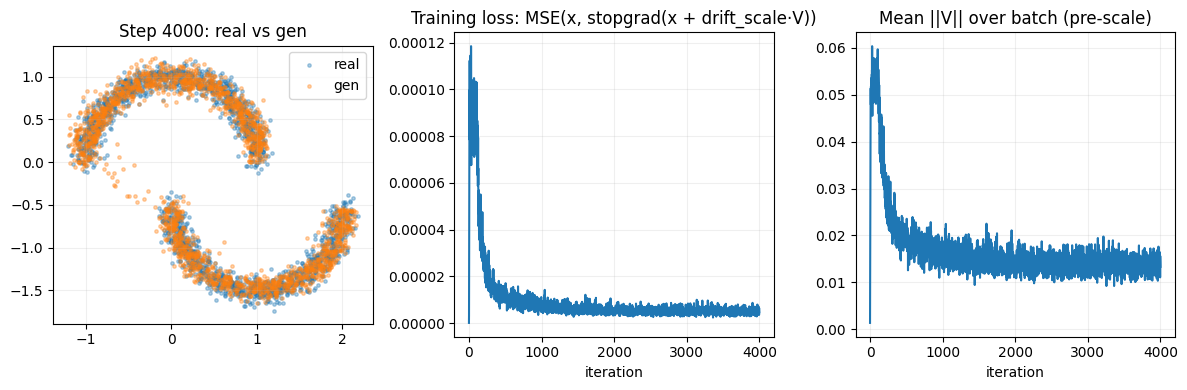

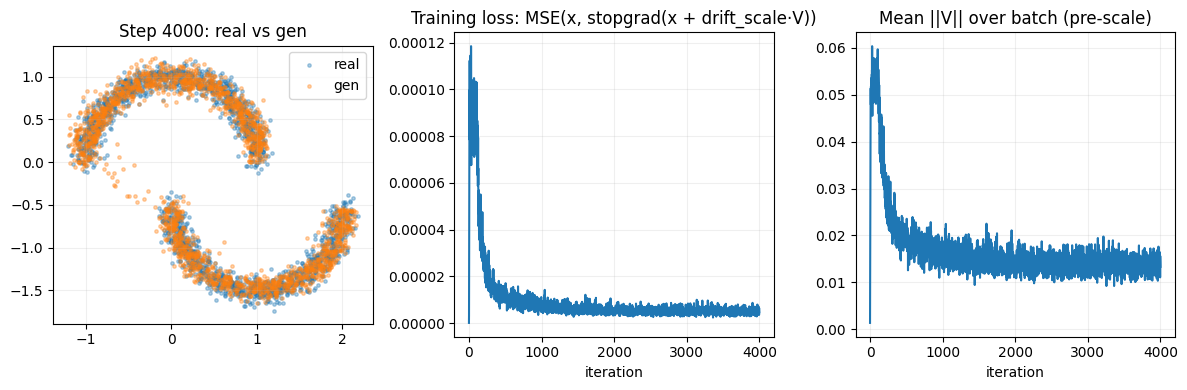

In [8]:
gen.eval()
fig = plot_training_state(
    sample_real=sample_real,
    sample_fake=lambda n: gen(gen.sample_z(n, device=device)).detach(),
    losses=losses,
    mean_v_norms=mean_v_norms,
    step=steps,
    n_vis=n_vis,
)
save_fig(fig, run_dir / "final.png")
fig